### Colab config

In [13]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [14]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content/drive/MyDrive/BREAST_CANCER_FL'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### Environment Setup & Imports

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

os.makedirs(os.path.join(BASE_PATH, 'models/federated/fedproto'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'results/federated/fedproto'), exist_ok=True)

print("="*70)
print("  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning")
print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cuda
  STEP 4 — FedProto (Prototype Representation Sharing) with Fine-Tuning


### Data Loading

In [16]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### Creating Directories

In [17]:
os.makedirs('models/domain_invariant', exist_ok=True)
os.makedirs('results/domain_invariant', exist_ok=True)
print(" Directories created")

 Directories created


### Load FedAvg Equal models as starting point

In [18]:
# ============================================================
# FIND AND LOAD CORRECT H2 MODEL
# Retrain from local baseline, not from FedAvg Equal
# ============================================================

# Load from Phase 3 LOCAL trained models instead
# Then let DI-FL find its own best weights
model_h1_di = Hospital1_MLP(input_size=23, dropout_rate=0.3).to(device)
model_h1_di.load_state_dict(
    torch.load('models/trained/hospital1_local.pth', map_location=device)
)

model_h2_di = Hospital2_MLP(input_size=9, dropout_rate=0.3).to(device)
model_h2_di.load_state_dict(
    torch.load('models/trained/hospital2_local.pth', map_location=device)
)

model_h3_di = Hospital3_CNN(dropout_rate=0.2).to(device)
model_h3_di.load_state_dict(
    torch.load('models/trained/hospital3_local.pth', map_location=device)
)

print(" Loaded from Phase 3 LOCAL models")
print("   DI-FL will train from scratch like other FL methods")
print("   This ensures fair comparison with FedAvg Equal")

 Loaded from Phase 3 LOCAL models
   DI-FL will train from scratch like other FL methods
   This ensures fair comparison with FedAvg Equal


### Domain-Invariant Loss Function

In [19]:
# ============================================================
# DOMAIN-INVARIANT LOSS — Center Loss
# Pulls embeddings of same class closer together
# across all hospitals
# ============================================================

class CenterLoss(nn.Module):
    """
    Center loss: encourages embeddings of same class
    to cluster around class centers
    """
    def __init__(self, num_classes=2, embedding_dim=64, device='cuda'):
        super(CenterLoss, self).__init__()
        self.num_classes = num_classes
        self.embedding_dim = embedding_dim
        self.device = device

        # Class centers: learned parameters
        self.centers = nn.Parameter(
            torch.randn(num_classes, embedding_dim).to(device)
        )

    def forward(self, embeddings, labels):
        """
        embeddings: (batch_size, embedding_dim)
        labels: (batch_size,) with values 0 or 1
        """
        batch_size = embeddings.size(0)

        # Get center for each sample's class
        centers_batch = self.centers[labels.long()]  # (batch_size, embedding_dim)

        # L2 distance from embedding to its class center
        loss = torch.norm(embeddings - centers_batch, p=2, dim=1).mean()

        return loss

center_loss = CenterLoss(
    num_classes=2,
    embedding_dim=EMBEDDING_DIM,
    device=device
)

print(" Center loss initialized")
print(f"   Class centers shape: {center_loss.centers.shape}")

 Center loss initialized
   Class centers shape: torch.Size([2, 64])


### Evaluation Helper

In [20]:
def evaluate_model_di(model, dataloader, device):
    """Evaluate domain-invariant model"""
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend((outputs > 0.0).float().cpu().numpy())
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds = np.array(all_preds).flatten()
    all_probs = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss': running_loss / len(dataloader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc': auc
    }

print(" Evaluation function defined")

 Evaluation function defined


### Domain-Invariant Training Loop

In [22]:
# ============================================================
# DOMAIN-INVARIANT FEDERATED LEARNING
# Train with center loss to align embeddings across hospitals
# ============================================================

print("="*70)
print("  DOMAIN-INVARIANT FEDERATED LEARNING — Training")
print("="*70)

# Optimizers
opt_h1_enc = optim.Adam(model_h1_di.encoder.parameters(), lr=0.0008)
opt_h1_head = optim.Adam(model_h1_di.shared_head.parameters(), lr=0.0003)

opt_h2_enc = optim.Adam(model_h2_di.encoder.parameters(), lr=0.0008)
opt_h2_head = optim.Adam(model_h2_di.shared_head.parameters(), lr=0.0003)

opt_h3_proj = optim.Adam(model_h3_di.encoder.projection.parameters(), lr=0.0001)
opt_h3_head = optim.Adam(model_h3_di.shared_head.parameters(), lr=0.00005)

center_opt = optim.SGD(center_loss.parameters(), lr=0.5)

criterion = nn.BCEWithLogitsLoss()

# Hyperparameters
num_rounds = 25
local_epochs = 2
lambda_center = 0.5  # weight for center loss vs classification loss
equal_sizes = [1, 1, 1]  # equal weighting

di_history = {
    'round': [],
    'h1_test_acc': [], 'h1_test_f1': [], 'h1_test_auc': [],
    'h2_test_acc': [], 'h2_test_f1': [], 'h2_test_auc': [],
    'h3_test_acc': [], 'h3_test_f1': [], 'h3_test_auc': [],
    'avg_test_acc': []
}

best_di_loss = float('inf')

def train_local_di(model, dataloader, criterion, opt_enc, opt_head,
                   center_loss, center_opt, lambda_center, device):
    """
    Train with both classification loss and center loss
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float().view(-1, 1)
        labels_int = labels.squeeze().long()

        # Forward
        embeddings = model.get_embedding(inputs)
        outputs = model.shared_head(embeddings)

        # Classification loss
        cls_loss = criterion(outputs, labels)

        # Center loss (domain invariant)
        center_l = center_loss(embeddings, labels_int)

        # Total loss
        total_loss = cls_loss + (lambda_center * center_l)

        # Backward
        opt_enc.zero_grad(set_to_none=True)
        opt_head.zero_grad(set_to_none=True)
        center_opt.zero_grad(set_to_none=True)

        total_loss.backward()

        opt_enc.step()
        opt_head.step()
        center_opt.step()

        running_loss += cls_loss.item() * inputs.size(0)
        all_preds.extend((outputs.detach() > 0.0).float().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        running_loss / len(dataloader.dataset),
        accuracy_score(all_labels, all_preds)
    )

print(f"\nTraining parameters:")
print(f"  Rounds: {num_rounds}")
print(f"  Local epochs: {local_epochs}")
print(f"  Lambda (center loss weight): {lambda_center}")
print(f"  Weighting: Equal (33.3% each)")
print(f"\n{'Round':<8} {'H1 Acc':<10} {'H2 Acc':<10} {'H3 Acc':<10} {'Avg':<10}")
print(f"{'─'*50}")

for fl_round in range(num_rounds):

    # Local training with center loss
    for _ in range(local_epochs):
        train_local_di(
            model_h1_di, train_loader_h1, criterion,
            opt_h1_enc, opt_h1_head, center_loss, center_opt,
            lambda_center, device
        )

    for _ in range(local_epochs):
        train_local_di(
            model_h2_di, train_loader_h2, criterion,
            opt_h2_enc, opt_h2_head, center_loss, center_opt,
            lambda_center, device
        )

    for _ in range(local_epochs):
        train_local_di(
            model_h3_di, train_loader_h3, criterion,
            opt_h3_proj, opt_h3_head, center_loss, center_opt,
            lambda_center, device
        )

    # FedAvg on shared head
    def get_shared_head(m):
        return {k: v.clone() for k, v in m.shared_head.state_dict().items()}

    def set_shared_head(m, w):
        m.shared_head.load_state_dict(w)

    def fedavg_equal(w_list, sizes):
        total = sum(sizes)
        avg = {}
        for key in w_list[0].keys():
            avg[key] = sum(
                w_list[i][key].float() * (sizes[i] / total)
                for i in range(len(w_list))
            )
        return avg

    global_weights = fedavg_equal(
        [get_shared_head(model_h1_di),
         get_shared_head(model_h2_di),
         get_shared_head(model_h3_di)],
        equal_sizes
    )

    set_shared_head(model_h1_di, global_weights)
    set_shared_head(model_h2_di, global_weights)
    set_shared_head(model_h3_di, global_weights)

    # Evaluate
    m1 = evaluate_model_di(model_h1_di, test_loader_h1, device)
    m2 = evaluate_model_di(model_h2_di, test_loader_h2, device)
    m3 = evaluate_model_di(model_h3_di, test_loader_h3, device)

    avg_acc = np.mean([m1['accuracy'], m2['accuracy'], m3['accuracy']])

    di_history['round'].append(fl_round + 1)
    di_history['h1_test_acc'].append(m1['accuracy'])
    di_history['h1_test_f1'].append(m1['f1'])
    di_history['h1_test_auc'].append(m1['auc_roc'])
    di_history['h2_test_acc'].append(m2['accuracy'])
    di_history['h2_test_f1'].append(m2['f1'])
    di_history['h2_test_auc'].append(m2['auc_roc'])
    di_history['h3_test_acc'].append(m3['accuracy'])
    di_history['h3_test_f1'].append(m3['f1'])
    di_history['h3_test_auc'].append(m3['auc_roc'])
    di_history['avg_test_acc'].append(avg_acc)

    avg_loss = np.mean([m1['loss'], m2['loss'], m3['loss']])
    if avg_loss < best_di_loss:
        best_di_loss = avg_loss
        torch.save(model_h1_di.state_dict(),
                  'models/domain_invariant/best_h1_di.pth')
        torch.save(model_h2_di.state_dict(),
                  'models/domain_invariant/best_h2_di.pth')
        torch.save(model_h3_di.state_dict(),
                  'models/domain_invariant/best_h3_di.pth')
        torch.save(global_weights,
                  'models/domain_invariant/best_global_head_di.pth')

    if (fl_round + 1) % 5 == 0 or fl_round == 0:
        print(f"{fl_round+1:<8} {m1['accuracy']:<10.4f} "
              f"{m2['accuracy']:<10.4f} {m3['accuracy']:<10.4f} "
              f"{avg_acc:<10.4f}")

# Save history
di_history_serializable = {
    k: [float(v) for v in vals] if isinstance(vals[0], (float, int, np.floating, np.integer)) else vals
    for k, vals in di_history.items()
}
with open('results/domain_invariant/fl_history_di.json', 'w') as f:
    json.dump(di_history_serializable, f, indent=4)

print(f"\n Domain-Invariant FL complete")
print(f"   Best H2 accuracy: {max(di_history['h2_test_acc']):.4f}")
print(f"   FedAvg Equal was: 0.7917")
print(f"   Improvement: {max(di_history['h2_test_acc']) - 0.7917:+.4f}")

  DOMAIN-INVARIANT FEDERATED LEARNING — Training

Training parameters:
  Rounds: 25
  Local epochs: 2
  Lambda (center loss weight): 0.5
  Weighting: Equal (33.3% each)

Round    H1 Acc     H2 Acc     H3 Acc     Avg       
──────────────────────────────────────────────────
1        0.9649     0.7917     0.9421     0.8996    
5        0.9649     0.6667     0.9704     0.8673    
10       0.9649     0.6667     0.9798     0.8705    
15       0.9649     0.6250     0.9838     0.8579    
20       0.9649     0.6250     0.9825     0.8575    
25       0.9737     0.6250     0.9838     0.8608    

 Domain-Invariant FL complete
   Best H2 accuracy: 0.7917
   FedAvg Equal was: 0.7917
   Improvement: -0.0000


### Compare Domain-Invariant vs FedAvg Equal

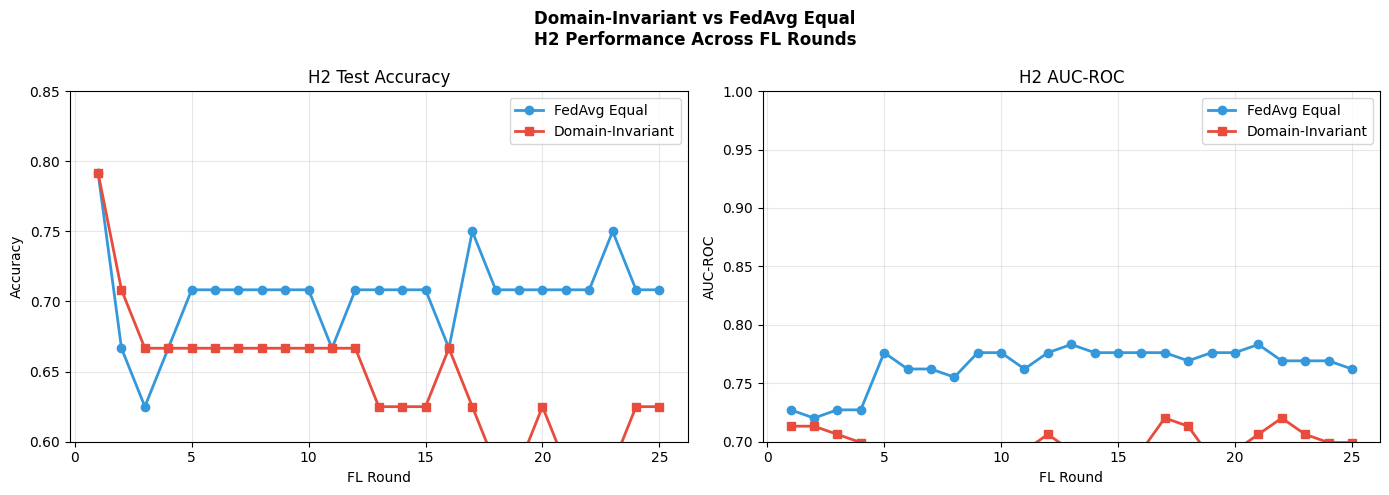

 Comparison plot saved


In [23]:
# ============================================================
# COMPARISON — Domain-Invariant vs FedAvg Equal
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Domain-Invariant vs FedAvg Equal\n'
    'H2 Performance Across FL Rounds',
    fontsize=12, fontweight='bold'
)

# Load FedAvg Equal history
with open('results/federated/equal/fl_history_eq.json', 'r') as f:
    fl_eq = json.load(f)

# Left: H2 Accuracy
axes[0].plot(fl_eq['round'], fl_eq['h2_test_acc'],
            color='#3498DB', linewidth=2, marker='o', label='FedAvg Equal')
axes[0].plot(di_history['round'], di_history['h2_test_acc'],
            color='#E74C3C', linewidth=2, marker='s', label='Domain-Invariant')
axes[0].set_title('H2 Test Accuracy')
axes[0].set_xlabel('FL Round')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.6, 0.85])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: H2 AUC
axes[1].plot(fl_eq['round'], fl_eq['h2_test_auc'],
            color='#3498DB', linewidth=2, marker='o', label='FedAvg Equal')
axes[1].plot(di_history['round'], di_history['h2_test_auc'],
            color='#E74C3C', linewidth=2, marker='s', label='Domain-Invariant')
axes[1].set_title('H2 AUC-ROC')
axes[1].set_xlabel('FL Round')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim([0.7, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/domain_invariant/comparison_h2.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Comparison plot saved")

### Summary

In [24]:
print("\n" + "="*70)
print("  DOMAIN-INVARIANT RESULTS")
print("="*70)

summary = f"""
FedAvg Equal Baseline:
  H2 Best Accuracy: {max(fl_eq['h2_test_acc']):.4f}

Domain-Invariant Learning:
  H2 Best Accuracy: {max(di_history['h2_test_acc']):.4f}
  Improvement:      {max(di_history['h2_test_acc']) - max(fl_eq['h2_test_acc']):+.4f}

Method Comparison:
  Local Only:       0.7083
  FedAvg Equal:     {max(fl_eq['h2_test_acc']):.4f}
  Domain-Invariant: {max(di_history['h2_test_acc']):.4f}
"""

print(summary)

with open('results/domain_invariant/summary.txt', 'w') as f:
    f.write(summary)


  DOMAIN-INVARIANT RESULTS

FedAvg Equal Baseline:
  H2 Best Accuracy: 0.7917

Domain-Invariant Learning:
  H2 Best Accuracy: 0.7917
  Improvement:      +0.0000

Method Comparison:
  Local Only:       0.7083
  FedAvg Equal:     0.7917
  Domain-Invariant: 0.7917

